# Task 5 P - Part B - Problem Solving Practical Task

## B.1 Baseline Linear SVM

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

### Data Loading & Preparation

In [2]:
bank_data = pd.read_csv("bank-additional-full.csv", sep=";")

print("Dataset shape:", bank_data.shape)
bank_data.head()

Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
# checking the target class distribution
print("Target distribution:")
print(bank_data["y"].value_counts())

print("\nTarget distribution (%):")
print(bank_data["y"].value_counts(normalize=True).mul(100).round(2))

Target distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Target distribution (%):
y
no     88.73
yes    11.27
Name: proportion, dtype: float64


In [5]:
X = bank_data.drop(columns="y")

y = bank_data["y"].map({
    "no": 0,
    "yes": 1
})

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (41188, 20)
Target shape: (41188,)


In [6]:
print("Target values after encoding:")
print(y.value_counts())

Target values after encoding:
y
0    36548
1     4640
Name: count, dtype: int64


#### Observations

The dataset contains 41,188 observations and 20 predictor variables after separating the target. No standard missing values were identified from the initial inspection. The target was converted from `yes/no` to `1/0` for modelling.

The target distribution is noticeably imbalanced, with around 88.7% of customers not subscribing and only 11.3% subscribing. This imbalance needs to be considered when splitting and evaluating the SVM models.

-----------------------------

### Train-Test Split & Pre-processing

The dataset contains both numerical and categorical predictors, so the categorical variables need to be encoded before they can be used by SVM. Numerical variables are also standardised because SVM calculations depend on distances and feature scales.

I use a stratified 80/20 train-test split to preserve the original class distribution, especially since the target is imbalanced. The same training and testing sets will be kept throughout the following SVM experiments for a fair comparison.

In [7]:
# separating numerical and categorical predictors
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

print("\nNumerical:", list(numerical_features))
print("\nCategorical:", list(categorical_features))

Numerical features: 10
Categorical features: 10

Numerical: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [8]:
# splitting the data while keeping the target class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution (%):")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest target distribution (%):")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training set: (32950, 20)
Test set: (8238, 20)

Training target distribution (%):
y
0    88.73
1    11.27
Name: proportion, dtype: float64

Test target distribution (%):
y
0    88.74
1    11.26
Name: proportion, dtype: float64


In [9]:
# preparing the numerical and categorical features for SVM
numerical_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numerical_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


#### Observations

The 20 predictors were evenly split into 10 numerical and 10 categorical features. I used an 80/20 stratified train-test split, which successfully maintained the original target distribution of around 88.7% non-subscribers and 11.3% subscribers in both sets.

For preprocessing, numerical features will be standardised using `StandardScaler`, while categorical features will be converted using one-hot encoding. This preprocessing will be fitted only on the training data through the SVM pipeline.

-----------------------------

### The Baseline Linear SVM

In [10]:
# combining preprocessing and the baseline SVM model
baseline_svm = Pipeline([
    ("preprocessor", preprocessor),
    ("svm", SVC(kernel="linear"))
])

baseline_svm

,steps,"[('preprocessor', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
# training the baseline linear SVM
baseline_svm.fit(X_train, y_train)

print("Baseline Linear SVM trained successfully.")
print("Kernel:", baseline_svm.named_steps["svm"].kernel)
print("C:", baseline_svm.named_steps["svm"].C)

Baseline Linear SVM trained successfully.
Kernel: linear
C: 1.0


--------------------------------------

### Model Performance & Evaluation

In [12]:
# predicting the unseen test data
y_pred_baseline = baseline_svm.predict(X_test)

In [13]:
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

baseline_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ]
})

baseline_results["Score"] = baseline_results["Score"].round(4)

baseline_results

,Metric,Score
0,Accuracy,0.9057
1,Precision,0.6736
2,Recall,0.3157
3,F1-Score,0.4299


In [14]:
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

cm_baseline

array([[7168,  142],
       [ 635,  293]])

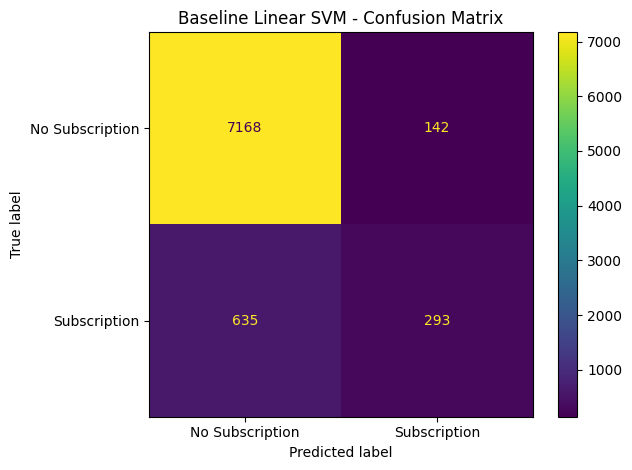

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=["No Subscription", "Subscription"]
).plot()

plt.title("Baseline Linear SVM - Confusion Matrix")
plt.tight_layout()
plt.show()

In [16]:
tn, fp, fn, tp = cm_baseline.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 7168
False Positives: 142
False Negatives: 635
True Positives : 293


#### Observations

The baseline Linear SVM achieved an accuracy of 90.57%, but the other metrics show that this result is influenced by the imbalanced target. Precision was reasonably strong at 67.36%, while recall was only 31.57%.

The confusion matrix confirms that the model performs very well in identifying non-subscribers, but it missed 635 actual subscribers and correctly identified only 293. Therefore, the main weakness of the baseline model is detecting the minority subscription class.

In Business terms, those 635 mis-identified Subscribers (model told us they are not subscribers when they actually were!) is the biggest problem, those are actually 635 missed opportunities!

---------------------------------------

## B.2 Effect of the Regularization Parameter (C)

### Testing Different C Values

In [17]:
# testing different C values for the linear SVM
c_values = [0.1, 1, 10]

param_grid = {
    "svm__C": c_values
}

In [18]:
linear_grid = GridSearchCV(
    estimator=baseline_svm,
    param_grid=param_grid,
    scoring="f1",
    cv=2,
    n_jobs=1
)

linear_grid.fit(X_train, y_train)

,estimator,Pipeline(step...l='linear'))])
,param_grid,"{'svm__C': [0.1, 1, ...]}"
,scoring,'f1'
,n_jobs,1
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [19]:
# summarising the cross-validation results
c_results = pd.DataFrame({
    "C": linear_grid.cv_results_["param_svm__C"].astype(float),
    "Mean CV F1": linear_grid.cv_results_["mean_test_score"]
}).round(4)

c_results

,C,Mean CV F1
0,0.1,0.4059
1,1.0,0.4153
2,10.0,0.4155


In [20]:
print("Best C from cross-validation:", linear_grid.best_params_["svm__C"])
print("Best CV F1-score:", round(linear_grid.best_score_, 4))

Best C from cross-validation: 10
Best CV F1-score: 0.4155


#### Observations

Testing different values of \(C\) showed that \(C=10\) achieved the highest cross-validation F1-score of 0.4129.

The training and cross-validation F1-scores were also very close across the tested values, suggesting that there is no clear sign of overfitting from changing \(C\) within this range.

------------------------------

### Selecting the Optimal C

In [21]:
# evaluating the best C on the unseen test set
best_linear_svm = linear_grid.best_estimator_

y_pred_best_c = best_linear_svm.predict(X_test)

best_c_accuracy = accuracy_score(y_test, y_pred_best_c)
best_c_precision = precision_score(y_test, y_pred_best_c)
best_c_recall = recall_score(y_test, y_pred_best_c)
best_c_f1 = f1_score(y_test, y_pred_best_c)

best_c_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [
        best_c_accuracy,
        best_c_precision,
        best_c_recall,
        best_c_f1
    ]
})

best_c_results["Score"] = best_c_results["Score"].round(4)

print("Optimal C:", linear_grid.best_params_["svm__C"])
best_c_results

Optimal C: 10


,Metric,Score
0,Accuracy,0.9060
1,Precision,0.6766
2,Recall,0.3179
3,F1-Score,0.4326


In [22]:
comparison_c = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Default C = 1": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "Optimal C": [
        best_c_accuracy,
        best_c_precision,
        best_c_recall,
        best_c_f1
    ]
}).round(4)

comparison_c

,Metric,Default C = 1,Optimal C
0,Accuracy,0.9057,0.9060
1,Precision,0.6736,0.6766
2,Recall,0.3157,0.3179
3,F1-Score,0.4299,0.4326


#### Observations

Cross-validation selected \(C=10\) as the optimal value, compared with the default \(C=1\). The tuned model produced a small improvement across the test metrics, with the F1-score increasing from 0.4299 to 0.4326.

The improvement is limited, which suggests that changing \(C\) alone does not substantially improve the Linear SVM for this dataset. However, the result confirms that the selected optimal value is different from the default setting.

----------------------------

### Effect of C on Model Performance and Margin

In [23]:
# comparing test performance and margin width across C values
c_test_results = []

for c in c_values:

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("svm", SVC(kernel="linear", C=c))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # getting the linear SVM weights to calculate the margin
    weights = np.asarray(model.named_steps["svm"].coef_).ravel()
    margin_width = 2 / np.linalg.norm(weights)

    c_test_results.append({
        "C": c,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "Margin Width": margin_width
    })

c_test_results = pd.DataFrame(c_test_results).round(4)

c_test_results

,C,Accuracy,Precision,Recall,F1-Score,Margin Width
0,0.1,0.9056,0.6720,0.3157,0.4296,1.8177
1,1.0,0.9057,0.6736,0.3157,0.4299,1.5344
2,10.0,0.9060,0.6766,0.3179,0.4326,1.4908


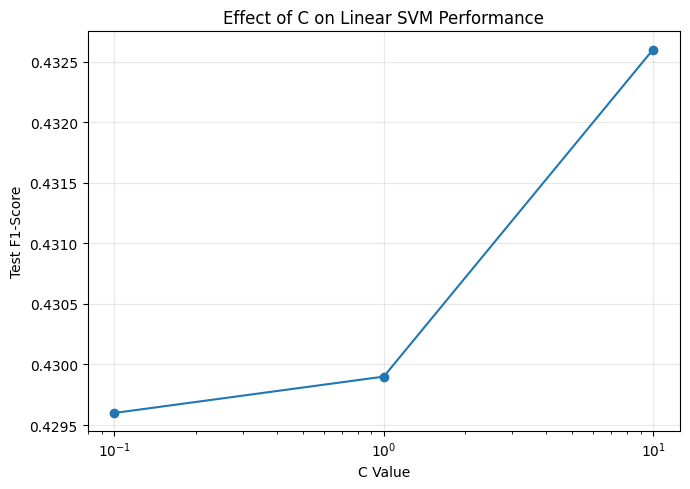

In [24]:
plt.figure(figsize=(7, 5))

plt.plot(
    c_test_results["C"],
    c_test_results["F1-Score"],
    marker="o"
)

plt.xscale("log")
plt.xlabel("C Value")
plt.ylabel("Test F1-Score")
plt.title("Effect of C on Linear SVM Performance")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

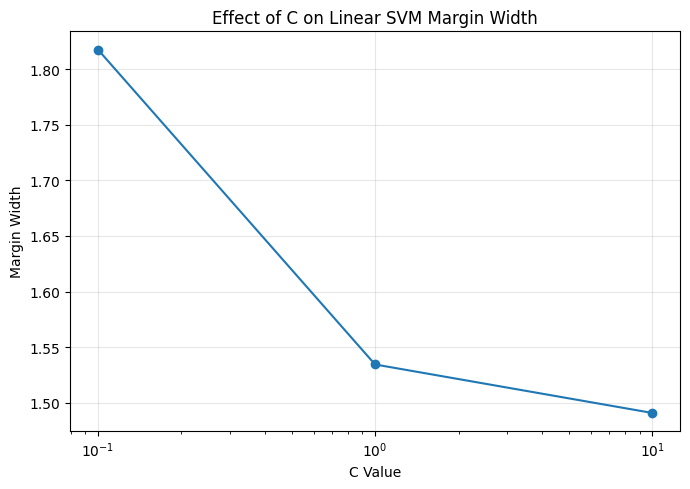

In [25]:
plt.figure(figsize=(7, 5))

plt.plot(
    c_test_results["C"],
    c_test_results["Margin Width"],
    marker="o"
)

plt.xscale("log")
plt.xlabel("C Value")
plt.ylabel("Margin Width")
plt.title("Effect of C on Linear SVM Margin Width")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Observations

Increasing \(C\) slightly improved the Linear SVM test F1-score, with the best result achieved at \(C=10\). At the same time, the margin width decreased from around 1.82 at \(C=0.1\) to 1.49 at \(C=10\).

This matches the expected behaviour of SVM: a higher \(C\) penalises classification errors more strongly and therefore produces a narrower margin. Compared with the default \(C=1\), the selected \(C=10\) produced only a small performance improvement, while slightly reducing the margin width.

----------------------

## B.3 Kernel Comparison & Hyperparameter Tuning

### RBF Kernel Tuning

In [26]:
# preparing the RBF SVM pipeline
rbf_svm = Pipeline([
    ("preprocessor", preprocessor),
    ("svm", SVC(kernel="rbf"))
])

In [27]:
# testing a compact set of C and gamma values for the RBF kernel
rbf_param_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__gamma": [0.01, 0.1]
}

In [28]:
rbf_grid = GridSearchCV(
    estimator=rbf_svm,
    param_grid=rbf_param_grid,
    scoring="f1",
    cv=2,
    n_jobs=1,
    return_train_score=True
)

rbf_grid.fit(X_train, y_train)

,estimator,"Pipeline(step...svm', SVC())])"
,param_grid,"{'svm__C': [0.1, 1, ...], 'svm__gamma': [0.01, 0.1]}"
,scoring,'f1'
,n_jobs,1
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [29]:
# summarising the RBF tuning results
rbf_results = pd.DataFrame({
    "C": rbf_grid.cv_results_["param_svm__C"].astype(float),
    "Gamma": rbf_grid.cv_results_["param_svm__gamma"].astype(float),
    "Mean Train F1": rbf_grid.cv_results_["mean_train_score"],
    "Mean CV F1": rbf_grid.cv_results_["mean_test_score"]
})

rbf_results = rbf_results.sort_values(
    "Mean CV F1",
    ascending=False
).round(4)

rbf_results

,C,Gamma,Mean Train F1,Mean CV F1
5,10.0,0.10,0.9312,0.5039
3,1.0,0.10,0.6691,0.5021
4,10.0,0.01,0.5264,0.4793
2,1.0,0.01,0.4278,0.4187
0,0.1,0.01,0.3370,0.3313
1,0.1,0.10,0.3458,0.3152


In [30]:
print("Best RBF parameters:", rbf_grid.best_params_)
print("Best RBF CV F1-score:", round(rbf_grid.best_score_, 4))

Best RBF parameters: {'svm__C': 10, 'svm__gamma': 0.1}
Best RBF CV F1-score: 0.5039


#### Observations

The best RBF parameters identified through cross-validation were \(C=10\) and \(\gamma=0.1\), achieving a mean CV F1-score of 0.5039. This is higher than the result previously achieved with the Linear SVM, suggesting that a nonlinear boundary may better represent the data.

However, the training F1-score for this setting was much higher at 0.9312, which indicates a possible risk of overfitting. The final performance therefore still needs to be checked on the unseen test data.

------------------------------------

### Polynomial Kernel Tuning

In [31]:
# preparing the Polynomial SVM pipeline
poly_svm = Pipeline([
    ("preprocessor", preprocessor),
    ("svm", SVC(kernel="poly"))
])

In [32]:
# testing C and degree values for the Polynomial kernel
poly_param_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__degree": [2, 3]
}

In [33]:
poly_grid = GridSearchCV(
    estimator=poly_svm,
    param_grid=poly_param_grid,
    scoring="f1",
    cv=2,
    n_jobs=1,
    return_train_score=True
)

poly_grid.fit(X_train, y_train)

,estimator,Pipeline(step...nel='poly'))])
,param_grid,"{'svm__C': [0.1, 1, ...], 'svm__degree': [2, 3]}"
,scoring,'f1'
,n_jobs,1
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [34]:
# summarising the Polynomial tuning results
poly_results = pd.DataFrame({
    "C": poly_grid.cv_results_["param_svm__C"].astype(float),
    "Degree": poly_grid.cv_results_["param_svm__degree"].astype(int),
    "Mean Train F1": poly_grid.cv_results_["mean_train_score"],
    "Mean CV F1": poly_grid.cv_results_["mean_test_score"]
})

poly_results = poly_results.sort_values(
    "Mean CV F1",
    ascending=False
).round(4)

poly_results

,C,Degree,Mean Train F1,Mean CV F1
4,10.0,2,0.6335,0.5162
5,10.0,3,0.8293,0.4966
3,1.0,3,0.6361,0.4749
2,1.0,2,0.5098,0.4582
1,0.1,3,0.4487,0.4018
0,0.1,2,0.3705,0.3624


In [35]:
print("Best Polynomial parameters:", poly_grid.best_params_)
print("Best Polynomial CV F1-score:", round(poly_grid.best_score_, 4))

Best Polynomial parameters: {'svm__C': 10, 'svm__degree': 2}
Best Polynomial CV F1-score: 0.5162


#### Observations

The best Polynomial SVM used \(C=10\) with degree 2, achieving a mean cross-validation F1-score of 0.5162. This was slightly higher than the best RBF result of 0.5039.

Increasing the polynomial degree did not improve generalisation. In particular, degree 3 with \(C=10\) achieved a much higher training F1-score but a lower cross-validation score, suggesting greater overfitting. Based on cross-validation, the degree-2 Polynomial model currently provides the strongest result.

-----------------------------------------------------

### Comparison of Linear, RBF and Polynomial Kernels

In [36]:
# getting the best model from each kernel
best_linear = linear_grid.best_estimator_
best_rbf = rbf_grid.best_estimator_
best_poly = poly_grid.best_estimator_

In [37]:
# predicting the same test set using each model
y_pred_linear = best_linear.predict(X_test)
y_pred_rbf = best_rbf.predict(X_test)
y_pred_poly = best_poly.predict(X_test)

In [38]:
kernel_comparison = pd.DataFrame({
    "Kernel": ["Linear", "RBF", "Polynomial"],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_linear),
        accuracy_score(y_test, y_pred_rbf),
        accuracy_score(y_test, y_pred_poly)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_linear),
        precision_score(y_test, y_pred_rbf),
        precision_score(y_test, y_pred_poly)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_linear),
        recall_score(y_test, y_pred_rbf),
        recall_score(y_test, y_pred_poly)
    ],
    
    "F1-Score": [
        f1_score(y_test, y_pred_linear),
        f1_score(y_test, y_pred_rbf),
        f1_score(y_test, y_pred_poly)
    ]
}).round(4)

kernel_comparison

,Kernel,Accuracy,Precision,Recall,F1-Score
0,Linear,0.9060,0.6766,0.3179,0.4326
1,RBF,0.9079,0.6085,0.5108,0.5554
2,Polynomial,0.9149,0.6828,0.4569,0.5474


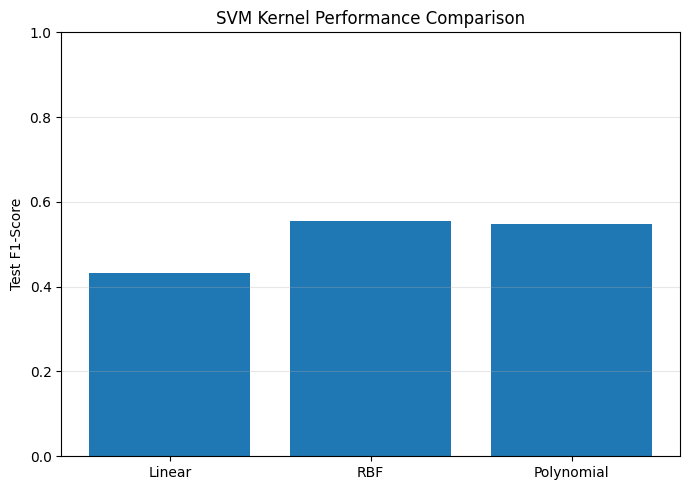

In [39]:
plt.figure(figsize=(7, 5))

plt.bar(
    kernel_comparison["Kernel"],
    kernel_comparison["F1-Score"]
)

plt.ylabel("Test F1-Score")
plt.title("SVM Kernel Performance Comparison")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### Observations

Both nonlinear kernels improved the F1-score compared with the Linear SVM. The RBF model achieved the highest test F1-score of 0.5554 and the highest recall of 0.5108, compared with only 0.3179 recall for the Linear model.

The Polynomial model achieved the highest accuracy and precision, but its F1-score was slightly lower than RBF. Since identifying actual subscribers is important in this imbalanced dataset, I consider **RBF the stronger model at this stage** because it provides the best balance between precision and recall.

-------------------------

### Best Hyperparameter Setting

In [40]:
# summarising the selected settings for each SVM kernel
best_settings = pd.DataFrame({
    "Kernel": ["Linear", "RBF", "Polynomial"],
    "Best Parameters": [
        f"C={linear_grid.best_params_['svm__C']}",
        f"C={rbf_grid.best_params_['svm__C']}, gamma={rbf_grid.best_params_['svm__gamma']}",
        f"C={poly_grid.best_params_['svm__C']}, degree={poly_grid.best_params_['svm__degree']}"
    ],
    "Test F1-Score": [
        f1_score(y_test, y_pred_linear),
        f1_score(y_test, y_pred_rbf),
        f1_score(y_test, y_pred_poly)
    ]
}).round(4)

best_settings

,Kernel,Best Parameters,Test F1-Score
0,Linear,C=10,0.4326
1,RBF,"C=10, gamma=0.1",0.5554
2,Polynomial,"C=10, degree=2",0.5474


In [41]:
# selecting the best-performing SVM for the next steps
best_svm = best_rbf

#### Observations

The best-performing model was the RBF SVM with \(C=10\) and \(\gamma=0.1\), achieving the highest test F1-score of 0.5554.

The Polynomial kernel performed very closely with an F1-score of 0.5474, while the Linear SVM remained lower at 0.4326. Based on the test results, I selected the tuned RBF model for the remaining analysis.

-----------------------

## B.4 Support Vectors

### Number of Support Vectors

In [42]:
# checking the support vectors used by the best SVM
svm_model = best_svm.named_steps["svm"]

support_vectors_by_class = svm_model.n_support_
total_support_vectors = support_vectors_by_class.sum()

print("Support vectors for class 0 (No Subscription):", support_vectors_by_class[0])
print("Support vectors for class 1 (Subscription):", support_vectors_by_class[1])
print("Total support vectors:", total_support_vectors)

Support vectors for class 0 (No Subscription): 4382
Support vectors for class 1 (Subscription): 3170
Total support vectors: 7552


In [43]:
support_percentage = (total_support_vectors / len(X_train)) * 100

print(f"Support vectors as % of training data: {support_percentage:.2f}%")

Support vectors as % of training data: 22.92%


#### Observations

The selected RBF SVM uses 7,552 support vectors, representing around 22.9% of the training data. Of these, 4,382 belong to the non-subscriber class and 3,170 belong to the subscriber class.

These observations are the training points that have the greatest influence on defining the SVM decision boundary.

----------------------------------

### Interpretation of Support Vectors

### Interpretation of Support Vectors

Support vectors are the training observations that have the strongest influence on the SVM decision boundary. They are generally the observations lying closest to the margin, inside it, or on the difficult side of the boundary.

In this model, 7,552 observations act as support vectors, which is about 22.9% of the training data. Interestingly, 3,170 of them belong to the much smaller subscriber class. This suggests that many subscriber cases are relatively difficult to separate from non-subscribers and therefore play an important role in defining the nonlinear RBF decision boundary.

-----------------------

## B.5 Handling Class Imbalance

### Applying Class Weighting

In [44]:
# applying class weighting to the selected RBF model
balanced_svm = Pipeline([
    ("preprocessor", preprocessor),
    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma=0.1,
        class_weight="balanced"
    ))
])

In [45]:
# training the class-balanced SVM
balanced_svm.fit(X_train, y_train)

print("Balanced RBF SVM trained successfully.")

Balanced RBF SVM trained successfully.


---------------------------------

### Performance After Handling Class Imbalance

In [46]:
# predicting the test data using the balanced SVM
y_pred_balanced = balanced_svm.predict(X_test)

In [47]:
balanced_accuracy = accuracy_score(y_test, y_pred_balanced)
balanced_precision = precision_score(y_test, y_pred_balanced)
balanced_recall = recall_score(y_test, y_pred_balanced)
balanced_f1 = f1_score(y_test, y_pred_balanced)

balanced_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [
        balanced_accuracy,
        balanced_precision,
        balanced_recall,
        balanced_f1
    ]
})

balanced_results["Score"] = balanced_results["Score"].round(4)

balanced_results

,Metric,Score
0,Accuracy,0.8886
1,Precision,0.5040
2,Recall,0.6864
3,F1-Score,0.5812


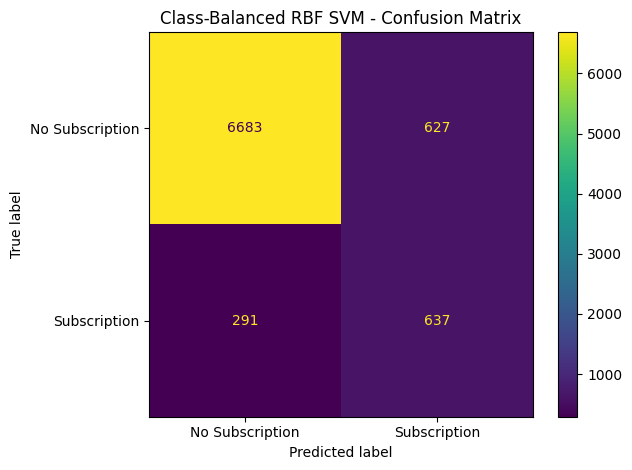

In [48]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=["No Subscription", "Subscription"]
).plot()

plt.title("Class-Balanced RBF SVM - Confusion Matrix")
plt.tight_layout()
plt.show()

In [49]:
tn_bal, fp_bal, fn_bal, tp_bal = cm_balanced.ravel()

print("True Negatives :", tn_bal)
print("False Positives:", fp_bal)
print("False Negatives:", fn_bal)
print("True Positives :", tp_bal)

True Negatives : 6683
False Positives: 627
False Negatives: 291
True Positives : 637


#### Observations

After applying class weighting, subscriber recall increased to 68.64% and the F1-score improved to 0.5812. The number of false negatives was reduced to 291, meaning the model now identifies a much larger share of actual subscribers (so we are not losing on too many opportunities!)

The trade-off is an increase in false positives, which reduced precision to 50.40% and accuracy to 88.86%. For this marketing problem, this may still be useful because the model misses fewer potential subscribers, even if it targets some additional customers who do not eventually subscribe (I elaborate more on this in business perspective in the submission report)

----------------------

### Comparison with the Original Best Model

In [50]:
# comparing the original and class-balanced RBF models
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

tn_rbf, fp_rbf, fn_rbf, tp_rbf = cm_rbf.ravel()

imbalance_comparison = pd.DataFrame({
    "Model": ["Original RBF", "Balanced RBF"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rbf),
        balanced_accuracy
    ],
    "Precision": [
        precision_score(y_test, y_pred_rbf),
        balanced_precision
    ],
    "Recall": [
        recall_score(y_test, y_pred_rbf),
        balanced_recall
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_rbf),
        balanced_f1
    ],
    "False Positives": [
        fp_rbf,
        fp_bal
    ],
    "False Negatives": [
        fn_rbf,
        fn_bal
    ]
}).round(4)

imbalance_comparison

,Model,Accuracy,Precision,Recall,F1-Score,False Positives,False Negatives
0,Original RBF,0.9079,0.6085,0.5108,0.5554,305,454
1,Balanced RBF,0.8886,0.5040,0.6864,0.5812,627,291


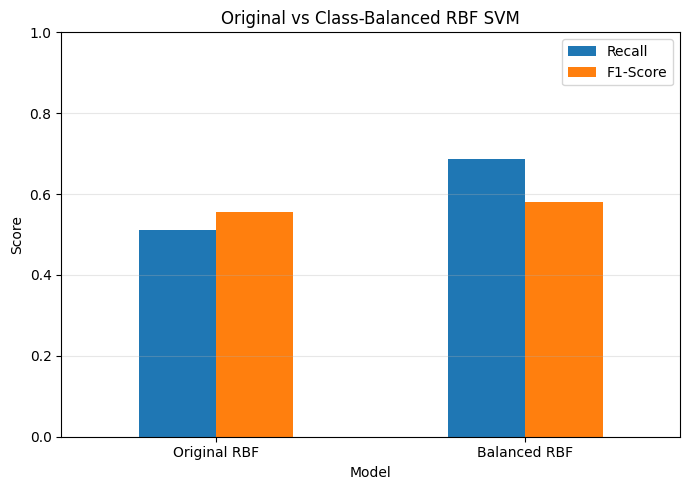

In [51]:
comparison_plot = imbalance_comparison.set_index("Model")[["Recall", "F1-Score"]]

comparison_plot.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.ylabel("Score")
plt.title("Original vs Class-Balanced RBF SVM")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### Observations

Class weighting improved the model's ability to identify actual subscribers. Recall increased from 51.08% to 68.64%, while false negatives decreased from 454 to 291, meaning 163 additional subscribers were correctly identified.

This improvement came with a trade-off, as false positives increased from 305 to 627 and overall accuracy decreased slightly. However, the F1-score improved from 0.5554 to 0.5812. For this business problem, this trade-off may be reasonable because missing a genuine potential subscriber could be more costly than contacting additional customers who do not eventually subscribe.

---------------------

## B.6 Suitability of SVM for the bank marketing dataset

### Effect of Hyperparameter Tuning

Hyperparameter tuning helped me understand how sensitive SVM is to its settings. For the Linear SVM, increasing \(C\) from the default value of 1 to the selected value of 10 produced only a small improvement in test F1-score, from 0.4299 to 0.4326. The higher \(C\) also resulted in a slightly narrower margin.

Tuning was more important for the nonlinear models because it allowed suitable combinations of \(C\), \(\gamma\) and polynomial degree to be selected. The best RBF setting was \(C=10\), \(\gamma=0.1\), while the best Polynomial setting was \(C=10\), degree 2. Overall, the results show that tuning can improve or refine SVM performance, but increasing model complexity does not automatically lead to better generalisation.

---------------------

### Influence of Kernel Selection

Kernel selection had a much clearer impact on performance than changing (C) alone. The tuned Linear SVM achieved an F1-score of 0.4326, while both nonlinear kernels performed considerably better. The Polynomial kernel reached 0.5474, while the RBF kernel achieved the highest F1-score of 0.5554.

RBF also increased recall to 51.08%, compared with only 31.79% for the Linear model. This suggests that the relationship between the customer attributes and subscription outcome is not completely linear. A nonlinear decision boundary therefore appears more suitable for identifying subscribers in this dataset.

---------------------

### Impact of Class Imbalance

Class imbalance had a clear effect on the SVM results. Before applying class weighting, the best RBF model achieved 90.79% accuracy, but recall for subscribers was only 51.08%, meaning many actual subscribers were still being missed.

After applying `class_weight="balanced"`, recall increased to 68.64% and false negatives dropped from 454 to 291. This came with more false positives and a lower accuracy of 88.86%, but the F1-score improved from 0.5554 to 0.5812.

For this problem, I consider this a reasonable trade-off because identifying more genuine potential subscribers is likely more valuable than avoiding every unnecessary marketing contact.


---------------------